In [7]:
## load dataset
import pandas as pd

df = pd.read_csv("student_exam_performance_dataset.csv")

In [8]:
## EDA
print(f"Cek 5 data teratas:\n{df.head()}\n")
print(f"Cek tipe data \n {df.dtypes} \n")
print(f"Cek missing values \n {df.isnull().sum()}")

Cek 5 data teratas:
  student_id  gender  age parental_education family_income internet_access  \
0     S00001    Male   17        High School        Medium             Yes   
1     S00002  Female   18        High School           Low             Yes   
2     S00003    Male   17        High School        Medium              No   
3     S00004    Male   18           Bachelor        Medium             Yes   
4     S00005    Male   18           Bachelor        Medium             Yes   

  study_environment  study_hours_per_day  attendance_rate  sleep_hours  ...  \
0             Quiet                 2.98             96.5         6.05  ...   
1             Quiet                 4.45             95.7         6.96  ...   
2             Quiet                 3.75             76.0         7.02  ...   
3             Quiet                 2.03             72.6         6.23  ...   
4             Quiet                 5.14             87.3         8.54  ...   

   online_courses_completed  tutorin

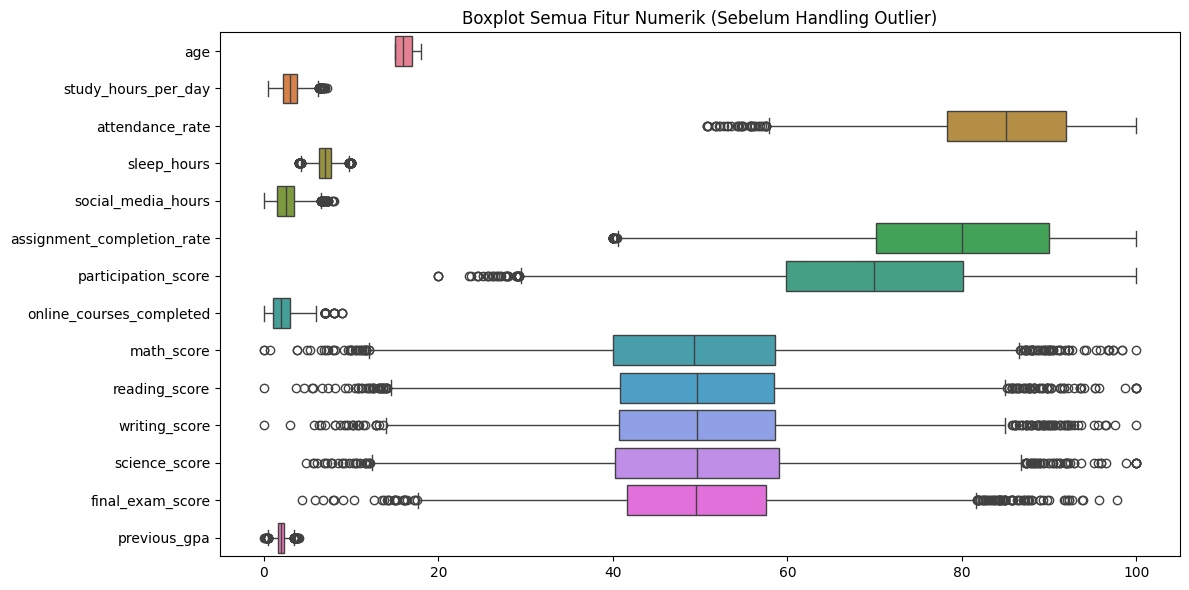

Jumlah outlier per kolom sebelum handling:
age: 0
study_hours_per_day: 27
attendance_rate: 36
sleep_hours: 63
social_media_hours: 36
assignment_completion_rate: 30
participation_score: 35
online_courses_completed: 49
math_score: 90
reading_score: 99
writing_score: 82
science_score: 77
final_exam_score: 95
previous_gpa: 62


In [9]:
## Cek outlier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# --- Pilih kolom numerik ---
num_cols = df.select_dtypes(include="number").columns

# --- 0️⃣ Convert kolom ke numeric (handle string / unknown) ---
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # invalid -> NaN

# Optional: isi NaN dengan median supaya bisa cek outlier
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 1️⃣ Visualisasi boxplot sebelum handling
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient='h')
plt.title("Boxplot Semua Fitur Numerik (Sebelum Handling Outlier)")
plt.tight_layout()
plt.show()

# 2️⃣ Hitung jumlah outlier per kolom pakai IQR
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outliers

print("Jumlah outlier per kolom sebelum handling:")
for k, v in outlier_summary.items():
    print(f"{k}: {v}")


Jumlah outlier setelah handling:
age: 0
study_hours_per_day: 0
attendance_rate: 0
sleep_hours: 0
social_media_hours: 0
assignment_completion_rate: 0
participation_score: 0
online_courses_completed: 0
math_score: 0
reading_score: 0
writing_score: 0
science_score: 0
final_exam_score: 0
previous_gpa: 0


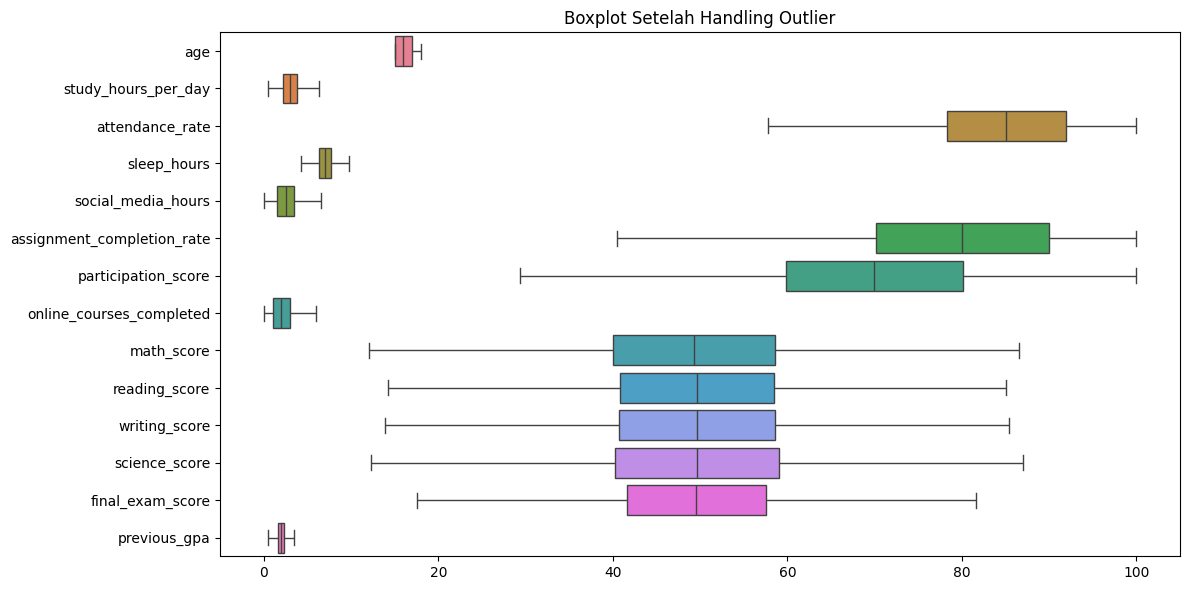

In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

strategy = 'cap'  # pilihan: 'remove', 'cap', 'robust'

df_handled = df.copy()
if strategy == 'robust':
    # Robust scaling (tidak menghapus outlier, hanya menstabilkan distribusi)
    scaler = RobustScaler()
    df_handled[num_cols] = scaler.fit_transform(df_handled[num_cols])

else:
    if strategy == 'remove':
        # Buat mask global biar tidak kepotong berkali-kali
        mask = np.ones(len(df_handled), dtype=bool)

    for col in num_cols:
        Q1 = df_handled[col].quantile(0.25)
        Q3 = df_handled[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        if strategy == 'remove':
            mask &= (df_handled[col] >= lower) & (df_handled[col] <= upper)

        elif strategy == 'cap':
            df_handled[col] = df_handled[col].clip(lower, upper)

    if strategy == 'remove':
        df_handled = df_handled[mask]
        
outlier_summary_after = {}
for col in num_cols:
    Q1 = df_handled[col].quantile(0.25)
    Q3 = df_handled[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df_handled[col] < lower) | (df_handled[col] > upper)).sum()
    outlier_summary_after[col] = outliers

print("\nJumlah outlier setelah handling:")
for k, v in outlier_summary_after.items():
    print(f"{k}: {v}")

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_handled[num_cols], orient='h')
plt.title("Boxplot Setelah Handling Outlier")
plt.tight_layout()
plt.show()

In [11]:
## encoding + preprocessing + smote
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

target = "parental_education"

# 1. SPLIT FEATURE & TARGET
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. AUTO DETECT CATEGORICA
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# 3. FIT ENCODER HANYA DI TRAIN
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

# 4. BALIK KE DATAFRAME & GABUNG
train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

X_train_final = pd.concat([X_train.drop(columns=categorical_cols), train_encoded_df], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_cols), test_encoded_df], axis=1)

# 3. SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_final, y_train)

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

# model
model=GaussianNB()

# training
model.fit(X_train_final,y_train)

# prediction
y_pred=model.predict(X_test_final)

print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

    Bachelor       0.00      0.00      0.00       755
 High School       0.00      0.00      0.00       751
      Master       0.00      0.00      0.00       388
         PhD       0.05      1.00      0.10       106

    accuracy                           0.05      2000
   macro avg       0.01      0.25      0.03      2000
weighted avg       0.00      0.05      0.01      2000

PhD    2000
Name: count, dtype: int64
parental_education
Bachelor       755
High School    751
Master         388
PhD            106
Name: count, dtype: int64


c:\Users\fakhri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fakhri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fakhri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(